<a href="https://colab.research.google.com/github/nalinkai/Data-Science-Project-Lifecycle/blob/Dev/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split # ML
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler # Scaling

In [ ]:
# Load the data
df = pd.read_csv('/content/drive/MyDrive/Data Science Project Lifecycle/Hotel-A-train_finalized.csv')
print(df.head())

   Reservation-id   Age    Income  Adults  Children  Babies  \
0        39428300  40.0  0.000000     2.0       2.0     0.0   
1        77491756  49.0  0.666667     3.0       3.0     0.0   
2        73747291  42.0  0.000000     3.0       3.0     0.0   
3        67301739  25.0  1.000000     4.0       3.0     0.0   
4        77222321  62.0  0.333333     1.0       1.0     0.0   

   Visted_Previously  Previous_Cancellations Reservation_Status  \
0                  0                       0          check-out   
1                  0                       0          check-out   
2                  0                       0          check-out   
3                  0                       0          check-out   
4                  0                       0          check-out   

   Discount_Rate  ...  Educational_Level_high-school  \
0          0.250  ...                          False   
1          0.000  ...                          False   
2          0.000  ...                          Fal

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26989 entries, 0 to 26988
Data columns (total 55 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Reservation-id                  26989 non-null  int64  
 1   Age                             26989 non-null  float64
 2   Income                          26989 non-null  float64
 3   Adults                          26989 non-null  float64
 4   Children                        26989 non-null  float64
 5   Babies                          26989 non-null  float64
 6   Visted_Previously               26989 non-null  int64  
 7   Previous_Cancellations          26989 non-null  int64  
 8   Reservation_Status              26989 non-null  object 
 9   Discount_Rate                   26989 non-null  float64
 10  Room_Rate                       26989 non-null  float64
 11  lead_time_days                  26989 non-null  float64
 12  stay_duration_days              

,Reservation-id,Age,Income,Adults,Children,Babies,Visted_Previously,Previous_Cancellations,Discount_Rate,Room_Rate,...,previous_stays_cancelled_ratio,is_online_booking,is_direct_booking,is_agent_booking,used_promotion,price_per_person,lead_time_price_interaction,cancellation_risk,stays_include_weekend,Reservation_Status_encoded
count,2.698900e+04,26989.000000,26989.000000,26989.000000,26989.000000,26989.000000,26989.000000,26989.000000,26989.000000,26989.000000,...,26989.000000,26989.000000,26989.000000,26989.000000,26989.000000,26989.000000,26989.000000,26989.000000,26989.000000,26989.000000
mean,5.016750e+07,44.009485,0.431694,2.333840,1.743562,0.352292,0.333136,0.113491,0.312359,0.501239,...,0.056745,0.566527,0.288673,0.144800,0.751454,0.099629,56.189771,0.034403,0.378710,0.925859
std,2.887913e+07,15.309557,0.342796,1.176541,0.722559,0.573694,0.471343,0.317198,0.280240,0.292491,...,0.158599,0.495564,0.453154,0.351905,0.432178,0.066584,55.600721,0.133566,0.485075,0.474121
min,3.154000e+03,18.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.524031e+07,31.000000,0.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.125000,0.246667,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.045333,13.386667,0.000000,0.000000,1.000000
50%,5.014160e+07,44.000000,0.333333,2.000000,2.000000,0.000000,0.000000,0.000000,0.250000,0.500000,...,0.000000,1.000000,0.000000,0.000000,1.000000,0.092222,38.760000,0.000000,0.000000,1.000000
75%,7.520460e+07,57.000000,0.666667,3.000000,2.000000,1.000000,1.000000,0.000000,0.500000,0.760000,...,0.000000,1.000000,1.000000,0.000000,1.000000,0.142857,83.526667,0.000000,1.000000,1.000000
max,9.999900e+07,70.000000,1.000000,5.000000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,...,0.500000,1.000000,1.000000,1.000000,1.000000,0.333333,519.360000,1.000000,1.000000,2.000000


In [ ]:
# Define Features (X) and Target (y)
target_col = 'Reservation_Status_encoded'
drop_cols = ['Reservation-id', 'Reservation_Status', target_col]

X = df.drop(columns=drop_cols)
y = df[target_col]

print("\nFeatures shape:", X.shape)
print("Target distribution:")
print(y.value_counts())


Features shape: (26989, 52)
Target distribution:
Reservation_Status_encoded
1    20774
0     4108
2     2107
Name: count, dtype: int64


In [ ]:
# Convert any boolean columns to int (0/1)
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")


Training samples: 21591
Testing samples: 5398


In [ ]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Train KNN Model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [ ]:
# Predictions & Evaluation
y_pred = knn.predict(X_test_scaled)

print("\n KNN Model Performance")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Canceled (0)', 'Check-out (1)', 'No-show (2)']))


 KNN Model Performance
Accuracy: 0.7355

Classification Report:
               precision    recall  f1-score   support

 Canceled (0)       0.21      0.09      0.13       822
Check-out (1)       0.77      0.94      0.85      4155
  No-show (2)       0.26      0.01      0.02       421

     accuracy                           0.74      5398
    macro avg       0.42      0.35      0.33      5398
 weighted avg       0.65      0.74      0.67      5398



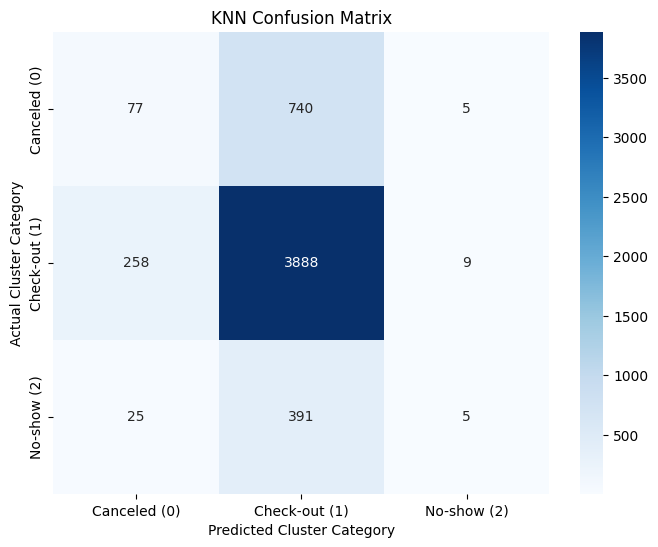

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Canceled (0)', 'Check-out (1)', 'No-show (2)'],
            yticklabels=['Canceled (0)', 'Check-out (1)', 'No-show (2)'])
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted Cluster Category')
plt.ylabel('Actual Cluster Category')
plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.21      0.09      0.13       822
           1       0.77      0.94      0.85      4155
           2       0.26      0.01      0.02       421

    accuracy                           0.74      5398
   macro avg       0.42      0.35      0.33      5398
weighted avg       0.65      0.74      0.67      5398



In [ ]:
# Find Best K Value
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    y_pred_temp = knn_temp.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_temp)
    accuracies.append(acc)

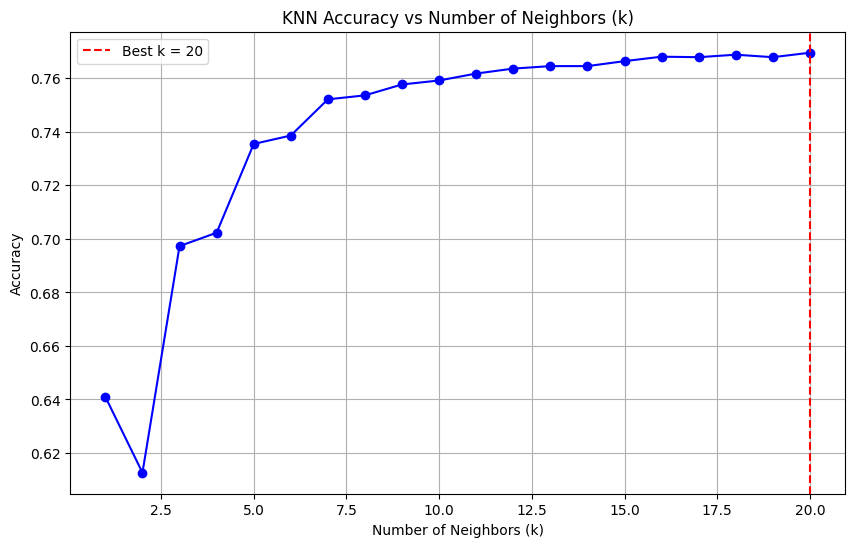


Best k found: 20 with accuracy: 0.7695


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='b')
plt.title('KNN Accuracy vs Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.axvline(x=np.argmax(accuracies)+1, color='r', linestyle='--', label=f'Best k = {np.argmax(accuracies)+1}')
plt.legend()
plt.show()

print(f"\nBest k found: {np.argmax(accuracies)+1} with accuracy: {max(accuracies):.4f}")

In [ ]:
# Retrain with Best K
best_k = np.argmax(accuracies) + 1
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred_best = knn_best.predict(X_test_scaled)

print(f"\nFinal KNN (k={best_k}) Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(classification_report(y_test, y_pred_best, target_names=['Canceled (0)', 'Check-out (1)', 'No-show (2)']))


Final KNN (k=20) Accuracy: 0.7695
               precision    recall  f1-score   support

 Canceled (0)       0.40      0.01      0.01       822
Check-out (1)       0.77      1.00      0.87      4155
  No-show (2)       0.00      0.00      0.00       421

     accuracy                           0.77      5398
    macro avg       0.39      0.34      0.29      5398
 weighted avg       0.65      0.77      0.67      5398



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Save the model
import joblib
joblib.dump(knn_best, 'knn_hotel_reservation_model.pkl')
print("\nModel saved as 'knn_hotel_reservation_model.pkl'")


Model saved as 'knn_hotel_reservation_model.pkl'
